In [1]:
# Feature Engineering — AI4I 2020 Predictive Maintenance Dataset

This notebook documents the feature engineering decisions made before model training.
Each new feature is motivated by physical domain knowledge about CNC machine behaviour.

SyntaxError: invalid syntax (722383611.py, line 3)

In [2]:
# Feature Engineering — AI4I 2020 Predictive Maintenance Dataset

This notebook documents the feature engineering decisions made before model training.
Each new feature is motivated by physical domain knowledge about CNC machine behaviour.

SyntaxError: invalid syntax (722383611.py, line 3)

# Feature Engineering — AI4I 2020 Predictive Maintenance Dataset

This notebook documents the feature engineering decisions made before model training.
Each new feature is motivated by physical domain knowledge about CNC machine behaviour.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')

from src.data_loader import load_raw_data

df = load_raw_data(filepath='../data/raw/ai4i2020.csv')

# Create engineered features
df['temp_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

print("Engineered features created:")
print(df[['temp_difference', 'power', 'Machine failure']].describe())

Data loaded successfully: 10000 rows, 14 columns
Engineered features created:
       temp_difference         power  Machine failure
count     10000.000000  10000.000000     10000.000000
mean         10.000630  59967.147040         0.033900
std           1.001094  10193.093881         0.180981
min           7.600000  10966.800000         0.000000
25%           9.300000  53105.400000         0.000000
50%           9.800000  59883.900000         0.000000
75%          11.000000  66873.750000         0.000000
max          12.100000  99980.400000         1.000000


C:\Users\babaw\AppData\Local\Temp\ipykernel_47168\3344213940.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\babaw\AppData\Local\Temp\ipykernel_47168\3344213940.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


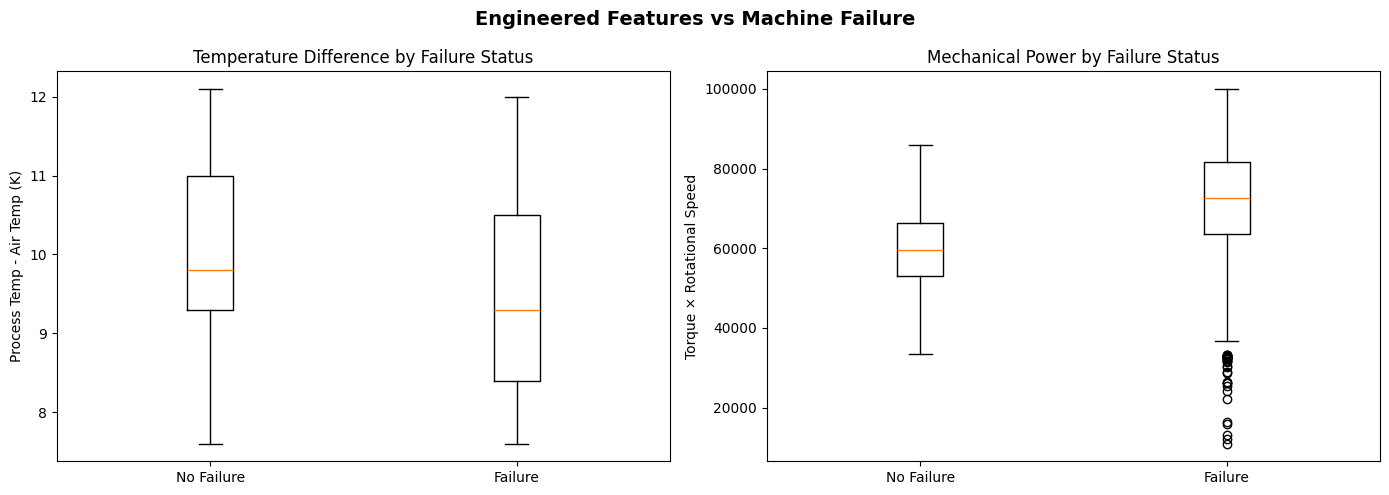

In [4]:
# Visualise engineered features vs failure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# temp_difference by failure
axes[0].boxplot(
    [df[df['Machine failure']==0]['temp_difference'],
     df[df['Machine failure']==1]['temp_difference']],
    labels=['No Failure', 'Failure']
)
axes[0].set_title('Temperature Difference by Failure Status', fontsize=12)
axes[0].set_ylabel('Process Temp - Air Temp (K)')

# power by failure
axes[1].boxplot(
    [df[df['Machine failure']==0]['power'],
     df[df['Machine failure']==1]['power']],
    labels=['No Failure', 'Failure']
)
axes[1].set_title('Mechanical Power by Failure Status', fontsize=12)
axes[1].set_ylabel('Torque × Rotational Speed')

plt.suptitle('Engineered Features vs Machine Failure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()